# Transfer Learning and Fine-Tuning of ResNet-50 for Image Classification on CIFAR-100

## Objective

Fine-tune a ResNet18 model pretrained on ImageNet to classify images in the CIFAR-100 dataset using transfer learning and fine-tuning.

## Introduction

This project shows how to fine-tune a pretrained image classification model to recognize pictures from the CIFAR-100 dataset. Instead of training a model from scratch, I used a ready-made model called ResNet-50, which has already learned useful image features from a large dataset.

By using transfer learning, I first train only the last layer (the “head”) of the model on CIFAR-100, then fine-tune deeper layers to improve accuracy. The dataset contains 100 different categories, such as animals, vehicles, and objects, which makes it great for testing how well the model can learn from different types of images.

In the end, the model can correctly predict what’s in new images, showing how fine-tuning a pretrained model can save time, improve results, and make deep learning easier for real-world image tasks.

## About the Datasets

CIFAR-100 DatasetThe CIFAR-100 dataset is a standard and challenging benchmark in computer vision research used primarily for image classification tasks. It consists of 60,000 color images, each a low-resolution size of $32 \times 32$ pixels. This dataset is split into a 50,000-image training set and a 10,000-image test set. A key feature that makes CIFAR-100 difficult is its high number of categories, containing 100 distinct "fine" classes (e.g., 'otter', 'maple tree'). These fine classes are hierarchically grouped into 20 "coarse" superclasses (e.g., 'aquatic mammals', 'trees'), allowing for both fine-grained and broader classification experiments.

Microsoft ResNet-50 ArchitectureResNet-50, or Residual Network with 50 layers, is a deeply influential Convolutional Neural Network (CNN) architecture developed by Microsoft Research. This model was created to overcome the performance degradation and vanishing gradient problem that plagued very deep neural networks at the time. Its primary innovation is the introduction of the residual block, which utilizes skip connections or shortcut paths that bypass one or more layers. These connections allow the original input, $x$, to be added directly to the output of the layer stack, forcing the network to learn only the residual mapping instead of the entire function. By incorporating 50 such layers in its structure, ResNet-50 enabled the successful training of significantly deeper models, making it a state-of-the-art model widely used for tasks like image classification and a popular backbone for transfer learning on smaller datasets like CIFAR-100.

## Import Libraries

This section brings in all the external tools (called libraries or modules) that the project needs to run. Each library provides specific functions.

In [1]:
# Import necessary libraries

import torch, torchvision
from torch import nn, optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score

from tqdm.auto import tqdm
from PIL import Image

import matplotlib.pyplot as plt
import numpy as np
import random

In [2]:
# Import the Drive module from Google Colab and mount it to the Colab environment to access files stored in Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Define the Hyperparameters

In this section, I set the key training settings that control how the model learns.
These settings are called hyperparameters because they are defined before training begins. They’re not learned by the model itself.

In [3]:
# Define key hyperparameters for training

IMG_SIZE = 224      # The input image size (224x224) — required by ResNet-50
BATCH_SIZE = 50     # Number of images processed in one forward/backward pass
EPOCH_HEAD = 10     # Number of epochs to train only the classification head
EPOCH_FINE = 35     # Number of epochs for fine-tuning deeper layers
LR_HEAD = 1e-3      # Learning rate for training the classification head (faster learning)
LR_FINE = 1e-4      # Lower learning rate for fine-tuning pretrained layers (prevents overfitting)
SEED = 44           # Random seed for reproducibility — ensures consistent results

## Load the Pretrained Model

In this step, a pretrained deep learning model called **ResNet-50**, developed by Microsoft, is loaded.
The model has been trained on millions of images from the **ImageNet** dataset and has learned to identify general visual patterns such as edges, shapes, and textures.

By using this pretrained model, training does not begin from scratch. Instead, its existing knowledge is reused and fine-tuned on the **CIFAR-100** dataset to enable recognition of 100 specific image categories.

This method, known as **transfer learning**, helps save time, lower training costs, and enhance accuracy even when working with smaller datasets.


In [4]:
# Load the pretrained model (Resnet-50 Model)

resnet_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 168MB/s]


In [5]:
# Apply the default preprocessing transforms
# that match the training setup of the pre-trained ResNet50 model

models.ResNet50_Weights.DEFAULT.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

## Create Preprocessing Pipeline

This step prepares the images before sending them into the model.
The preprocessing pipeline resizes, normalizes, and converts each image into the right format expected by the pretrained model (ResNet-50).

It ensures all images have the same size, color format, and pixel range so the model can understand them correctly during training and testing.

In [6]:
# Create preprocessing pipeline
# transformation pipeline for the data

train_transforms = transforms.Compose([                 # Define sequence of image transformations
    transforms.RandomResizedCrop(IMG_SIZE),             # Randomly crop and resize image to target size
    transforms.RandomHorizontalFlip(),                  # Randomly flip image horizontally (data augmentation)
    transforms.ToTensor(),                              # Convert image to PyTorch tensor
    transforms.Normalize(                               # Normalize using ImageNet mean and std
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


## Load CIFAR-100 Dataset from Hugging Face

In this step, the **CIFAR-100** dataset is downloaded directly from the **Hugging Face Hub** using the `datasets` library.
The dataset consists of **60,000 color images** across **100 classes**, with each class containing **600 images**.

Accessing it through Hugging Face simplifies the process, allowing seamless loading, exploration, and use for training without the need for manual downloads or setup.

In [7]:
# Load dataset

data_path = "./cifar100_dataset"

dataset = datasets.CIFAR100(root=data_path, download=True, transform=train_transforms)

100%|██████████| 169M/169M [00:03<00:00, 49.4MB/s]


In [8]:
dataset

Dataset CIFAR100
    Number of datapoints: 50000
    Root location: ./cifar100_dataset
    Split: Train
    StandardTransform
Transform: Compose(
               RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

## Basic Info about CIFAR100 Dataset


The **CIFAR-100 dataset** is a collection of **60,000 color images** divided into **100 different classes**, such as animals, vehicles, and everyday objects.
Each image is **32×32 pixels** in size, and each class has **600 images**.

It is widely used for **image classification tasks** to test how well models can recognize and group different types of objects.


In [9]:
# Get the Class names

classes = dataset.classes

# Print the total number of classes and the list
print("Total number of classes:", len(classes))
print("Class names:")
print(classes)

Total number of classes: 100
Class names:
['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'tu

In [10]:
dataset.data   # Input features

array([[[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [195, 205, 193],
         [212, 224, 204],
         [182, 194, 167]],

        [[255, 255, 255],
         [254, 254, 254],
         [254, 254, 254],
         ...,
         [170, 176, 150],
         [161, 168, 130],
         [146, 154, 113]],

        [[255, 255, 255],
         [254, 254, 254],
         [255, 255, 255],
         ...,
         [189, 199, 169],
         [166, 178, 130],
         [121, 133,  87]],

        ...,

        [[148, 185,  79],
         [142, 182,  57],
         [140, 179,  60],
         ...,
         [ 30,  17,   1],
         [ 65,  62,  15],
         [ 76,  77,  20]],

        [[122, 157,  66],
         [120, 155,  58],
         [126, 160,  71],
         ...,
         [ 22,  16,   3],
         [ 97, 112,  56],
         [141, 161,  87]],

        [[ 87, 122,  41],
         [ 88, 122,  39],
         [101, 134,  56],
         ...,
         [ 34,  36,  10],
        

In [11]:
dataset.targets  # Output labels

[19,
 29,
 0,
 11,
 1,
 86,
 90,
 28,
 23,
 31,
 39,
 96,
 82,
 17,
 71,
 39,
 8,
 97,
 80,
 71,
 74,
 59,
 70,
 87,
 59,
 84,
 64,
 52,
 42,
 64,
 8,
 17,
 47,
 65,
 21,
 22,
 81,
 11,
 24,
 84,
 78,
 45,
 49,
 97,
 56,
 76,
 11,
 90,
 89,
 78,
 73,
 14,
 87,
 9,
 71,
 6,
 47,
 20,
 98,
 47,
 36,
 55,
 72,
 43,
 51,
 35,
 83,
 33,
 27,
 53,
 92,
 50,
 15,
 89,
 36,
 18,
 89,
 46,
 33,
 42,
 39,
 64,
 75,
 38,
 23,
 42,
 66,
 77,
 49,
 18,
 46,
 15,
 35,
 69,
 95,
 83,
 75,
 99,
 73,
 93,
 55,
 39,
 4,
 97,
 61,
 93,
 51,
 69,
 56,
 84,
 59,
 64,
 94,
 4,
 11,
 33,
 68,
 38,
 20,
 33,
 34,
 32,
 46,
 53,
 88,
 67,
 70,
 64,
 53,
 64,
 8,
 96,
 87,
 30,
 20,
 30,
 66,
 19,
 76,
 87,
 52,
 62,
 35,
 63,
 40,
 4,
 99,
 63,
 74,
 53,
 26,
 95,
 48,
 27,
 33,
 29,
 39,
 79,
 32,
 46,
 64,
 28,
 85,
 32,
 82,
 78,
 39,
 54,
 28,
 66,
 65,
 72,
 21,
 64,
 62,
 72,
 0,
 44,
 7,
 12,
 19,
 11,
 31,
 61,
 79,
 45,
 81,
 79,
 98,
 43,
 46,
 67,
 80,
 68,
 74,
 48,
 81,
 94,
 86,
 69,
 39,
 73,
 2

## Basic Info about the Pretrained Model

ResNet-50 is a deep convolutional neural network created by Microsoft Research.
It has 50 layers and uses a special technique called residual connections that helps the model learn better and avoid problems like vanishing gradients.

This model was trained on the ImageNet dataset, which contains over 1 million images and 1,000 object categories.
Because of this, ResNet-50 already understands general visual patterns and can be fine-tuned to perform well on new tasks like CIFAR-100 image classification.

In [12]:
# Resnet Model

resnet_model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Splitting the Dataset

In this step, the dataset is divided into training, validation and testing parts.
The training set is used to teach the model to recognize patterns, while the testing set is used to check how well the model performs on new, unseen images.

In [13]:
# split data into train, validation, and test
n = len(dataset)  # Total samples

val_size = int(0.2 * n)  # 20% for validation
test_size = int(0.2 * n) # 20% for test
train_size = n - val_size - test_size  # Remaining 60% for training

# split data
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size], torch.Generator().manual_seed(SEED))  # Use same random seed

## Prepare Dataloaders

The dataset is organized into **batches** using a **DataLoader**.
The DataLoader helps load images and labels in small groups instead of all at once, making training faster and more memory-efficient.

It also **shuffles** the data to prevent the model from learning in a fixed order, which improves training accuracy and generalization.


In [14]:
# Prepare dataloaders

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)  # Shuffle training data
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)     # Number of input features in last layer
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)   # Replace fully connected layer with new one

In [ ]:
# for x, y in train_loader:
#     print(y)

# This block is used to debug or inspect the data loader.

## Replace the ResNet Classification Head for CIFAR-100

In this step, the final layer (classification head) of the pretrained **ResNet-50** model is modified to align with the **100 classes** in the **CIFAR-100** dataset.
The original ResNet-50 was trained on **ImageNet**, which contains **1,000 classes**, so this layer is replaced with a new one designed to output **100 class predictions**.

This adjustment enables the model to adapt its learned features to the specific categories present in the CIFAR-100 dataset.

In [15]:
# resnet_model.fc

num_classes = 100
# (2048 -> 100)
# (2048 -> 1000)

num_features = resnet_model.fc.in_features

# swap the classification head
resnet_model.fc = nn.Linear(num_features, num_classes)

## Inspect Model Parameters in Resnet Before Training

Here, the parameters of the ResNet-50 model are inspected before training begins.
This helps verify the model’s structure, confirm that the layers have been properly loaded, and ensure that only the intended layers (such as the newly added classification head) will be updated during training.

In [16]:
# Inspect model parameters in Resnet

for param in resnet_model.parameters():
     print(param)

Streaming output truncated to the last 5000 lines.
        2.4717, 2.1721, 1.9654, 2.9141, 2.2997, 2.0517, 3.2925, 2.1472, 1.8631,
        3.1182, 2.2752, 2.4814, 2.5940, 1.8417, 3.0514, 2.9708, 2.5209, 2.2752,
        2.7768, 2.8290, 2.7711, 1.9431, 2.2267, 2.2885, 2.5403, 2.2340, 3.0228,
        3.1027, 4.1674, 3.2425, 2.5349, 2.3253, 2.6113, 2.7270, 2.0020, 2.3322,
        1.5061, 3.8564, 1.4470, 1.9374, 2.1910, 3.0360, 2.8936, 2.2124, 2.0753,
        2.0958, 2.5628, 3.0316, 2.4724, 2.3875, 2.3660, 3.0809, 2.1834, 2.7951,
        2.0768, 2.8028, 2.3331, 2.2506, 2.0954, 2.6680, 2.4188, 2.0533, 3.4870,
        2.9383, 1.8871, 2.7440, 3.1207, 2.5742, 2.2622, 2.4449, 2.6575, 3.1511,
        2.0887, 3.1083, 2.9955, 1.5633, 2.5520, 3.3401, 3.0937, 1.9202, 2.7642,
        3.2537, 3.6018, 2.9370, 2.7997, 2.4498, 2.8565, 1.6633, 2.4186, 3.0873,
        2.9388, 2.0651, 2.0924, 2.6021, 2.2021, 2.7498, 2.1334, 1.8892, 2.6674,
        2.8041, 2.9092, 3.2848, 3.2248, 2.8921, 2.7588, 2.9054, 2.529

## Freeze The Model Parameters

This keeps the pretrained knowledge from the original model (ResNet-50) while allowing only the new classification layer to learn from the CIFAR-100 data.

Freezing parameters helps speed up training and prevents the model from forgetting what it already knows.

In [17]:
# Freeze the model parameters

for param in resnet_model.parameters():  # Loop through all parameters
    param.requires_grad=False            # Freeze all layers

# unfreezing the classification head
for param in resnet_model.fc.parameters():
    param.requires_grad=True

criterion = nn.CrossEntropyLoss()        # Define loss function for classification
optimizer = torch.optim.Adam(            # Use Adam optimizer for head training
    filter(lambda p: p.requires_grad, resnet_model.parameters()), lr=LR_HEAD
)

## Transferring Model to GPU

The **model** and **data** are transferred to the **GPU (Graphics Processing Unit)** to accelerate the training process.
GPUs are capable of performing multiple computations simultaneously, which significantly enhances the speed of deep learning tasks such as image classification.

Utilizing a GPU enables the model to train more efficiently compared to relying solely on the CPU.

In [18]:
# Check availability

torch.cuda.is_available()

True

In [19]:
# Transfer model to GPU

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


# resnet_model.to(device)

device(type='cuda')

## Define Function To Train The Model

The function loops through the training images, compares the model’s predictions with the true labels, and updates the weights to reduce errors.

It helps the model improve its accuracy step by step over several epochs.

In [20]:
# Define a function to train and validate a classification model

def train(model, train_loader, criterion, optimizer, epochs):
    """
    Trains a classification model using the provided data loader, optimizer, and loss function.
    Also evaluates the model on a validation dataset after each epoch.
    """

    # Move the model to the computation device
    model.to(device)

    # Loop over the number of epochs (complete passes through the dataset)
    for epoch in range(epochs):
        model.train()  # Set the model to training mode (enables dropout, batchnorm, etc.)

        # Initialize accumulators for training loss and predictions
        train_total_loss = 0.0
        train_preds, train_targets = [], []

        # TRAINING LOOP
        # tqdm creates a progress bar for each epoch
        for x, y in tqdm(train_loader, leave=False, desc=f"Epoch {epoch+1}/{epochs}"):
            # Move the input data (x) and labels (y) to the GPU/CPU
            x, y = x.to(device), y.to(device)

            # Reset (zero) all the accumulated gradients before each batch
            optimizer.zero_grad()

            # Forward pass: send the batch through the model to get predictions
            logits = model(x)

            # Optional debug info (can be commented out for cleaner logs)
            # print(f"Input length: {len(x)}")
            # print(f"Input dimension: {x.shape}")

            # Compute the loss between predictions and true labels
            loss = criterion(logits, y)

            # Display loss and batch-level predictions for monitoring
            # print(f"Batch loss: {loss:.4}")
            # print(f"Batch Prediction: {logits.argmax(dim=1).tolist()}")

            # Backward pass: calculate gradients for each parameter
            loss.backward()

            # Optimization step: update model parameters using gradients
            optimizer.step()

            # Add batch loss to total loss for epoch
            train_total_loss += loss.item()

            # Store predictions and true labels for accuracy calculation
            train_preds += logits.argmax(dim=1).tolist()
            train_targets += y.cpu().tolist()
        # END TRAINING LOOP

        # Compute average training loss and accuracy for the epoch
        train_epoch_loss = train_total_loss / len(train_loader)
        train_epoch_accuracy = accuracy_score(train_preds, train_targets)

        # VALIDATION LOOP
        model.eval()  # Switch model to evaluation mode (disables dropout, batchnorm updates)
        val_total_loss = 0.0
        val_preds, val_targets = [], []

        # Validation should not update gradients
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)

                # Forward pass on validation data
                logits = model(x)
                loss = criterion(logits, y)

                # Accumulate validation loss
                val_total_loss += loss.item()

                # Store predictions and true labels for accuracy
                val_preds += logits.argmax(dim=1).tolist()
                val_targets += y.cpu().tolist()

        # Compute average validation loss and accuracy
        val_epoch_loss = val_total_loss / len(val_loader)
        val_epoch_accuracy = accuracy_score(val_preds, val_targets)
        # END VALIDATION LOOP

        # Print epoch summary for both training and validation
        print(
           f"Epoch {epoch+1}/{epochs}: "
           f"train_loss = {train_epoch_loss:.4f}, train_accuracy = {train_epoch_accuracy:.4f} | "
           f"val_loss = {val_epoch_loss:.4f}, val_accuracy = {val_epoch_accuracy:.4f}"
        )

    # Return a success message after completing all epochs
    return "Model successfully trained!"


## Train The Model

In this stage, the **training process** is executed using the prepared data and the defined training function.
The model learns by continuously adjusting its weights as it processes each batch of images, gradually improving its classification accuracy.

Across multiple **epochs**, the **loss** value decreases while **accuracy** improves, indicating that the model is effectively learning from the **CIFAR-100** dataset.

In [21]:
# Train the model (head training set up)

train(resnet_model, train_loader, criterion, optimizer, EPOCH_HEAD)

Epoch 1/10:   0%|          | 0/600 [00:00<?, ?it/s]

Epoch 1/10: train_loss = 3.4944, train_accuracy = 0.2069 | val_loss = 3.0218, val_accuracy = 0.2896


Epoch 2/10:   0%|          | 0/600 [00:00<?, ?it/s]

Epoch 2/10: train_loss = 2.8846, train_accuracy = 0.3091 | val_loss = 2.7893, val_accuracy = 0.3247


Epoch 3/10:   0%|          | 0/600 [00:00<?, ?it/s]

...

Epoch 9/10:   0%|          | 0/600 [00:00<?, ?it/s]

Epoch 9/10: train_loss = 2.3843, train_accuracy = 0.4012 | val_loss = 2.4871, val_accuracy = 0.3857


Epoch 10/10:   0%|          | 0/600 [00:00<?, ?it/s]

Epoch 10/10: train_loss = 2.3650, train_accuracy = 0.4054 | val_loss = 2.4704, val_accuracy = 0.3841


'Model successfully trained!'

## Second Fine Tuning - Fine Tune Deeper Layers

In this stage, the focus shifts toward improving performance by extending training beyond the classifier head.
During the initial training phase, the main body of the model was **frozen** to preserve the knowledge learned from its original training.

At this point, the **core layers**—specifically *layer2*, *layer3*, *layer4*, and the *final fully connected (fc) layer* are **unfrozen** to enable further learning.

Training these deeper layers allows the model to fine-tune its internal representations, making them more aligned with the **CIFAR-100** classification task.
This fine-tuning step helps the model achieve optimal accuracy for the new dataset.

In [22]:
# Optional: Confirm which layers are trainable

for name, param in resnet_model.named_parameters():
    if param.requires_grad:
        print(f"Trainable layer: {name}")

Trainable layer: fc.weight
Trainable layer: fc.bias


In [23]:
# Unfreeze layer2, layer3, layer4, and the classification head (fc)

for name, param in resnet_model.named_parameters():

    # Unfreeze selected layers for fine-tuning
    if "layer2" in name or "layer3" in name or "layer4" in name or "fc" in name:
        param.requires_grad = True        # Trainable
    else:
        param.requires_grad = False       # Frozen

# Optimizer for fine-tuning
optimizer_2 = torch.optim.SGD(
    filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=LR_FINE,
    momentum=0.9
)


In [24]:
# Second fine tuning stage

train(resnet_model, train_loader, criterion, optimizer_2, EPOCH_FINE)  # Fine-tune selected layers


Epoch 1/35:   0%|          | 0/600 [00:00<?, ?it/s]

Epoch 1/35: train_loss = 2.1568, train_accuracy = 0.4539 | val_loss = 2.2114, val_accuracy = 0.4366


Epoch 2/35:   0%|          | 0/600 [00:00<?, ?it/s]

Epoch 2/35: train_loss = 1.9842, train_accuracy = 0.4868 | val_loss = 2.0995, val_accuracy = 0.4585


Epoch 3/35:   0%|          | 0/600 [00:00<?, ?it/s]

...

Epoch 34/35:   0%|          | 0/600 [00:00<?, ?it/s]

Epoch 34/35: train_loss = 1.2533, train_accuracy = 0.6544 | val_loss = 1.4836, val_accuracy = 0.5996


Epoch 35/35:   0%|          | 0/600 [00:00<?, ?it/s]

Epoch 35/35: train_loss = 1.2460, train_accuracy = 0.6582 | val_loss = 1.4849, val_accuracy = 0.5998


'Model successfully trained!'

## Image Prediction Function with Preprocessing

This function prepares a new image (resize, normalize, and convert) before sending it to the model.
It then predicts the most likely class the image belongs to from the CIFAR-100 categories.

In [25]:
# Predict function

def predict(model, image_path, categories, transform):
    img = Image.open(image_path).convert("RGB")   # Load and convert image to RGB
    img = transform(img).unsqueeze(0)             # Apply same transforms and add batch dimension
    with torch.no_grad():                         # Disable gradient calculation
        pred = model(img.to(device))              # Get model prediction
        output = pred.argmax(dim=1).item()        # Get class index
    return categories[output]                     # Return predicted class name


## Use the Fine Tuned Model For Predictiction

This step uses the trained model to predict labels for new images.
It tests how well the model can recognize objects it has never seen before.

In [26]:
# Use the fine-tuned model to make prediction

image_path = "/content/drive/MyDrive/apple_s_000022.png"

predict(resnet_model, image_path, classes, train_transforms)

'apple'

## Visualize Predictions (sample images with predicted vs true labels).

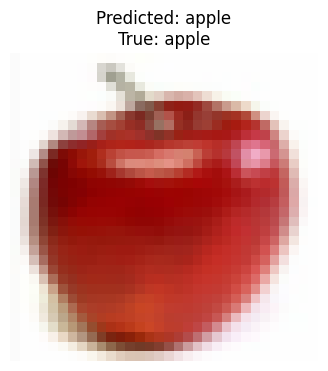

In [27]:
# Function to visualize a single prediction

image_path = "/content/drive/MyDrive/apple_s_000022.png"
true_label = "apple"


# Define the transform (MUST COME FIRST)

transform = transforms.Compose([
    transforms.Resize((224, 224)),     # Resize to match ResNet50 input size
    transforms.ToTensor(),             # Convert image to tensor
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],    # Standard ResNet mean/std
        std=[0.229, 0.224, 0.225]
    )
])

 # Visualize function
def visualize_single_prediction(model, image_path, true_label=None):

    # Load and convert image to RGB format
    img = Image.open(image_path).convert("RGB")

    # Apply CIFAR-100 transforms and add batch dimension
    img_tensor = transform(img).unsqueeze(0).to(device)

    # Set model to evaluation mode and predict
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        _, pred = torch.max(output, 1)        # Get index of predicted class
        pred_label = classes[pred.item()]     # Convert index → class name

    # Display the image with prediction
    plt.figure(figsize=(4,4))
    plt.imshow(np.array(img))

    # Display predicted and true label if provided
    if true_label is not None:
        plt.title(f"Predicted: {pred_label}\nTrue: {true_label}")
    else:
        plt.title(f"Predicted: {pred_label}")

    plt.axis("off")
    plt.show()


# Call the visualization function
visualize_single_prediction(resnet_model, image_path, true_label)

## Save the Fine Tuned Model

In [28]:
# Save fine-tuned model

model_path = "resnet50_cifar100_finetuned.pth"
torch.save(resnet_model.state_dict(), model_path)

# Download locally

from google.colab import files
files.download("resnet50_cifar100_finetuned.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary

This capstone project involved classifying images from the CIFAR-100 dataset using transfer learning with a pre-trained ResNet-50 model.

The strategy focused on progressive fine-tuning to adapt the network to the new dataset:

Initial Training:

The model was initially trained for a small number of epochs (3 to 5), but the accuracy was poor.

The number of epochs had to be increased to allow the classification layer to learn effectively.

Fine-Tuning Stages:

Attempt 1: Fine-tuning was started by unfreezing only Layer 4 and the fully connected layer of the ResNet-50, which did not result in a good performance improvement.

Attempt 2: The next step was to unfreeze Layer 3 and Layer 4 and the fully connected layer. This improved performance but was still insufficient.

Final Successful Stage: The best performance was achieved by unfreezing Layers 2, 3, and 4 and the fully connected layer(a larger portion of the pre-trained model) which finally improved the model's accuracy.

In essence, the project demonstrated that adapting a pre-trained CNN like ResNet-50 to a complex dataset like CIFAR-100 requires a strategic, multi-stage fine-tuning approach with sufficient training time.

## Recommendation

One of the major challenges faced was an unstable internet connection, which prevented training for more epochs, and in future work, I would  love to implement image augmentation and a scheduler to further improve the model's performance.